# 2 MPC
This notebook contains the CVXPY implementation of a MPC
This is the simplest one

### MPC Problem formulation

**Model Predictive Control** refers to the control approach of **numerically** solving a optimization problem at each time step. 

The controller generates a control signal over a fixed lenght T (Horizon) at each time step.

![mpc](img/mpc_block_diagram.png)

![mpc](img/mpc_t.png)

#### Linear MPC Formulation

Linear MPC makes use of the **LTI** (Linear time invariant) discrete state space model, wich represents a motion model used for Prediction.

$x_{t+1} = Ax_t + Bu_t$

The LTI formulation means that **future states** are linearly related to the current state and actuator signal. Hence, the MPC seeks to find a **control policy** U over a finite lenght horizon.

$U={u_{t|t}, u_{t+1|t}, ...,u_{t+T|t}}$

The objective function used minimize (drive the state to 0) is:

$
\begin{equation}
\begin{aligned}
\min_{} \quad &  \sum^{t+T-1}_{j=t} x^T_{j|t}Qx_{j|t} + u^T_{j|t}Ru_{j|t}\\
\textrm{s.t.} \quad &  x(0) = x0\\
  & x_{j+1|t} = Ax_{j|t}+Bu_{j|t}) \quad  \textrm{for} \quad t<j<t+T-1    \\
\end{aligned}
\end{equation}
$

Other linear constrains may be applied,for instance on the control variable:

$ U_{MIN} < u_{j|t} < U_{MAX}    \quad  \textrm{for} \quad t<j<t+T-1 $

The objective fuction accounts for quadratic error on deviation from 0 of the state and the control inputs sequences. Q and R are the **weight matrices** and are used to tune the response.

Because the goal is tracking a **reference signal** such as a trajectory, the objective function is rewritten as:

$
\begin{equation}
\begin{aligned}
\min_{} \quad &  \sum^{t+T-1}_{j=t} \delta x^T_{j|t}Q\delta x_{j|t} + u^T_{j|t}Ru_{j|t}
\end{aligned}
\end{equation}
$

where the error w.r.t desired state is accounted for:

$ \delta x = x_{j,t,ref} - x_{j,t} $

# Problem Formulation: Study case

In this case, the objective function to minimize is given by:

https://borrelli.me.berkeley.edu/pdfpub/IV_KinematicMPC_jason.pdf

$
\begin{equation}
\begin{aligned}
\min_{} \quad &  \sum^{t+T-1}_{j=t} (x_{j} - x_{j,ref})^TQ(x_{j} - x_{j,ref}) + \sum^{t+T-1}_{j=t+1} u^T_{j}Ru_{j} + (u_{j} - u_{j-1})^TP(u_{j} - u_{j-1}) \\
\textrm{s.t.} \quad &  x(0) = x0\\
  & x_{j+1} = Ax_{j}+Bu_{j} \quad  \textrm{for} \quad t<j<t+T-1  \\
  & u_{MIN} < u_{j} < u_{MAX} \quad  \textrm{for} \quad t<j<t+T-1 \\
  & \dot{u}_{MIN} < \frac{(u_{j} - u_{j-1})}{ts} < \dot{u}_{MAX} \quad  \textrm{for} \quad t+1<j<t+T-1 \\
\end{aligned}
\end{equation}
$


Where R,P,Q are the cost matrices used to tune the response.


## PRELIMINARIES

* linearized system dynamics
* function to represent the track
* function to represent the **reference trajectory** to track

In [1]:
import numpy as np
from scipy.integrate import odeint
from scipy.interpolate import interp1d
import cvxpy as cp

import matplotlib.pyplot as plt

plt.style.use("ggplot")

import time

In [2]:
"""
Control problem statement.
"""

N = 4  # number of state variables
M = 2  # number of control variables
T = 20  # Prediction Horizon
DT = 0.2  # discretization step


def get_linear_model(x_bar, u_bar):
    """
    Computes the LTI approximated state space model x' = Ax + Bu + C
    """

    L = 0.3  # vehicle wheelbase

    x = x_bar[0]
    y = x_bar[1]
    v = x_bar[2]
    theta = x_bar[3]

    a = u_bar[0]
    delta = u_bar[1]

    A = np.zeros((N, N))
    A[0, 2] = np.cos(theta)
    A[0, 3] = -v * np.sin(theta)
    A[1, 2] = np.sin(theta)
    A[1, 3] = v * np.cos(theta)
    A[3, 2] = v * np.tan(delta) / L
    A_lin = np.eye(N) + DT * A

    B = np.zeros((N, M))
    B[2, 0] = 1
    B[3, 1] = v / (L * np.cos(delta) ** 2)
    B_lin = DT * B

    f_xu = np.array(
        [v * np.cos(theta), v * np.sin(theta), a, v * np.tan(delta) / L]
    ).reshape(N, 1)
    C_lin = DT * (
        f_xu - np.dot(A, x_bar.reshape(N, 1)) - np.dot(B, u_bar.reshape(M, 1))
    )

    return np.round(A_lin, 4), np.round(B_lin, 4), np.round(C_lin, 4)


"""
the ODE is used to update the simulation given the mpc results
I use this insted of using the LTI twice
"""


def kinematics_model(x, t, u):
    """
    Returns the set of ODE of the vehicle model.
    """

    L = 0.3  # vehicle wheelbase
    dxdt = x[2] * np.cos(x[3])
    dydt = x[2] * np.sin(x[3])
    dvdt = u[0]
    dthetadt = x[2] * np.tan(u[1]) / L

    dqdt = [dxdt, dydt, dvdt, dthetadt]

    return dqdt


def predict(x0, u):
    """ """

    x_ = np.zeros((N, T + 1))

    x_[:, 0] = x0

    # solve ODE
    for t in range(1, T + 1):

        tspan = [0, DT]
        x_next = odeint(kinematics_model, x0, tspan, args=(u[:, t - 1],))

        x0 = x_next[1]
        x_[:, t] = x_next[1]

    return x_


def compute_path_from_wp(start_xp, start_yp, step=0.1):
    """
    Computes a reference path given a set of waypoints
    """

    final_xp = []
    final_yp = []
    delta = step  # [m]

    for idx in range(len(start_xp) - 1):
        section_len = np.sum(
            np.sqrt(
                np.power(np.diff(start_xp[idx : idx + 2]), 2)
                + np.power(np.diff(start_yp[idx : idx + 2]), 2)
            )
        )

        interp_range = np.linspace(0, 1, np.floor(section_len / delta).astype(int))

        fx = interp1d(np.linspace(0, 1, 2), start_xp[idx : idx + 2], kind=1)
        fy = interp1d(np.linspace(0, 1, 2), start_yp[idx : idx + 2], kind=1)

        final_xp = np.append(final_xp, fx(interp_range))
        final_yp = np.append(final_yp, fy(interp_range))

    dx = np.append(0, np.diff(final_xp))
    dy = np.append(0, np.diff(final_yp))
    theta = np.arctan2(dy, dx) # calculating the theta of the path based on the difference between pts

    return np.vstack((final_xp, final_yp, theta))


def get_nn_idx(state, path):
    """
    Computes the index of the waypoint closest to vehicle
    """

    dx = state[0] - path[0, :]
    dy = state[1] - path[1, :]
    dist = np.hypot(dx, dy)
    nn_idx = np.argmin(dist)

    try:
        v = [
            path[0, nn_idx + 1] - path[0, nn_idx],
            path[1, nn_idx + 1] - path[1, nn_idx],
        ]
        v /= np.linalg.norm(v)

        d = [path[0, nn_idx] - state[0], path[1, nn_idx] - state[1]]

        if np.dot(d, v) > 0:
            target_idx = nn_idx
        else:
            target_idx = nn_idx + 1

    except IndexError as e:
        target_idx = nn_idx

    return target_idx


def get_ref_trajectory(state, path, target_v):
    """
    Adapted from pythonrobotics
    """
    xref = np.zeros((N, T + 1))
    dref = np.zeros((1, T + 1))

    # sp = np.ones((1,T +1))*target_v #speed profile

    ncourse = path.shape[1]

    ind = get_nn_idx(state, path)

    xref[0, 0] = path[0, ind]  # X
    xref[1, 0] = path[1, ind]  # Y
    xref[2, 0] = target_v  # sp[ind] #V
    xref[3, 0] = path[2, ind]  # Theta
    dref[0, 0] = 0.0  # steer operational point should be 0

    dl = 0.05  # Waypoints spacing [m]
    travel = 0.0

    for i in range(T + 1):
        travel += abs(target_v) * DT  # current V or target V?
        dind = int(round(travel / dl))

        if (ind + dind) < ncourse:
            xref[0, i] = path[0, ind + dind]
            xref[1, i] = path[1, ind + dind]
            xref[2, i] = target_v  # sp[ind + dind]
            xref[3, i] = path[2, ind + dind]
            dref[0, i] = 0.0
        else:
            xref[0, i] = path[0, ncourse - 1]
            xref[1, i] = path[1, ncourse - 1]
            xref[2, i] = 0.0  # stop? #sp[ncourse - 1]
            xref[3, i] = path[2, ncourse - 1]
            dref[0, i] = 0.0

    return xref, dref

## MPC 

test single iteration

In [3]:
%%time

MAX_SPEED = 1.5  # m/s
MAX_STEER = np.radians(30)  # rad
MAX_ACC = 1.0
REF_VEL = 1.0

track = compute_path_from_wp([0, 3, 6], [0, 0, 0], 0.05)

# Starting Condition
x0 = np.zeros(N)
x0[0] = 0  # x
x0[1] = -0.25  # y
x0[2] = 0.0  # v
x0[3] = np.radians(-0)  # yaw

# starting guess
u_bar = np.zeros((M, T))
u_bar[0, :] = MAX_ACC / 2  # a
u_bar[1, :] = 0.1  # delta

# dynamics starting state w.r.t world frame
x_bar = np.zeros((N, T + 1))
x_bar[:, 0] = x0

# prediction for linearization of costrains
for t in range(1, T + 1):
    xt = x_bar[:, t - 1].reshape(N, 1)
    ut = u_bar[:, t - 1].reshape(M, 1)
    A, B, C = get_linear_model(xt, ut)
    xt_plus_one = np.squeeze(np.dot(A, xt) + np.dot(B, ut) + C)
    x_bar[:, t] = xt_plus_one

# CVXPY Linear MPC problem statement
x = cp.Variable((N, T + 1))
u = cp.Variable((M, T))
cost = 0
constr = []

# Cost Matrices
Q = np.diag([10, 10, 10, 10])  # state error cost
Qf = np.diag([10, 10, 10, 10])  # state  final error cost
R = np.diag([10, 10])  # input cost
R_ = np.diag([10, 10])  # input rate of change cost

# Get Reference_traj
x_ref, d_ref = get_ref_trajectory(x_bar[:, 0], track, REF_VEL)

# Prediction Horizon
for t in range(T):

    # Tracking Error
    cost += cp.quad_form(x[:, t] - x_ref[:, t], Q)

    # Actuation effort
    cost += cp.quad_form(u[:, t], R)

    # Actuation rate of change
    if t < (T - 1):
        cost += cp.quad_form(u[:, t + 1] - u[:, t], R_)

    # Kinrmatics Constrains (Linearized model)
    A, B, C = get_linear_model(x_bar[:, t], u_bar[:, t])
    constr += [x[:, t + 1] == A @ x[:, t] + B @ u[:, t] + C.flatten()]

# Final Point tracking
cost += cp.quad_form(x[:, T] - x_ref[:, T], Qf)

# sums problem objectives and concatenates constraints.
constr += [x[:, 0] == x_bar[:, 0]]  # starting condition
constr += [x[2, :] <= MAX_SPEED]  # max speed
constr += [x[2, :] >= 0.0]  # min_speed (not really needed)
constr += [cp.abs(u[0, :]) <= MAX_ACC]  # max acc
constr += [cp.abs(u[1, :]) <= MAX_STEER]  # max steer
# for t in range(T):
#     if t < (T - 1):
#         constr += [cp.abs(u[0,t] - u[0,t-1])/DT <= MAX_ACC]     #max acc
#         constr += [cp.abs(u[1,t] - u[1,t-1])/DT <= MAX_STEER]   #max steer

prob = cp.Problem(cp.Minimize(cost), constr)
solution = prob.solve(solver=cp.OSQP, verbose=True)

/tmp/ipykernel_606856/2643381836.py:27: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  A[0, 2] = np.cos(theta)
/tmp/ipykernel_606856/2643381836.py:28: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  A[0, 3] = -v * np.sin(theta)
/tmp/ipykernel_606856/2643381836.py:29: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  A[1, 2] = np.sin(theta)
/tmp/ipykernel_606856/2643381836.py:30: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will e

                                     CVXPY                                     
                                     v1.7.5                                    
-------------------------------------------------------------------------------
                                  Compilation                                  
-------------------------------------------------------------------------------
-------------------------------------------------------------------------------
                                Numerical solver                               
-------------------------------------------------------------------------------
-----------------------------------------------------------------
           OSQP v1.0.0  -  Operator Splitting QP Solver
              (c) The OSQP Developer Team
-----------------------------------------------------------------
problem:  variables n = 326, constraints m = 408
          nnz(P) + nnz(A) = 1063
settings: algebra = Built-in,
          OSQPInt 

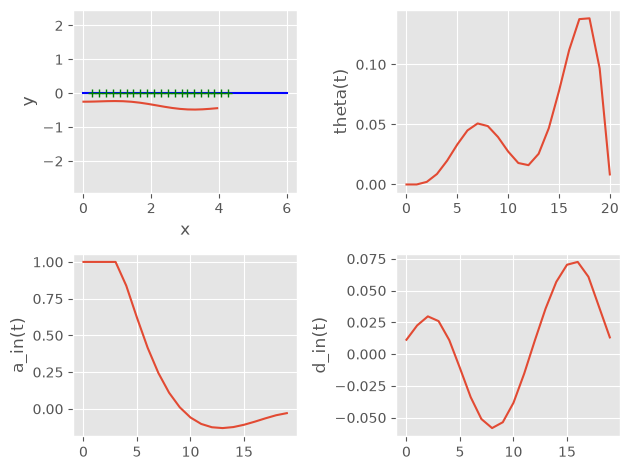

In [4]:
x_mpc = np.array(x.value[0, :]).flatten()
y_mpc = np.array(x.value[1, :]).flatten()
v_mpc = np.array(x.value[2, :]).flatten()
theta_mpc = np.array(x.value[3, :]).flatten()
a_mpc = np.array(u.value[0, :]).flatten()
delta_mpc = np.array(u.value[1, :]).flatten()

# simulate robot state trajectory for optimized U
x_traj = predict(x0, np.vstack((a_mpc, delta_mpc)))

# plt.figure(figsize=(15,10))
# plot trajectory
plt.subplot(2, 2, 1)
plt.plot(track[0, :], track[1, :], "b")
plt.plot(x_ref[0, :], x_ref[1, :], "g+")
plt.plot(x_traj[0, :], x_traj[1, :])
plt.axis("equal")
plt.ylabel("y")
plt.xlabel("x")

# plot v(t)
plt.subplot(2, 2, 3)
plt.plot(a_mpc)
plt.ylabel("a_in(t)")
# plt.xlabel('time')


plt.subplot(2, 2, 2)
plt.plot(theta_mpc)
plt.ylabel("theta(t)")

plt.subplot(2, 2, 4)
plt.plot(delta_mpc)
plt.ylabel("d_in(t)")

plt.tight_layout()
plt.show()

## full track demo

In [13]:
track = compute_path_from_wp(
    [0, 3, 4, 6, 10, 12, 14, 6, 1, 0], [0, 0, 2, 4, 3, 3, -2, -6, -2, -2], 0.05
)

# track = compute_path_from_wp([0,10,10,0],
#                              [0,0,1,1],0.05)

sim_duration = 200  # time steps
opt_time = []

x_sim = np.zeros((N, sim_duration))
u_sim = np.zeros((M, sim_duration - 1))

MAX_SPEED = 1.5  # m/s
MAX_ACC = 3.0  # m/ss
MAX_D_ACC = 1.0  # m/sss
MAX_STEER = np.radians(30)  # rad
MAX_D_STEER = np.radians(30)  # rad/s
REF_VEL = 1.0  # m/s

# Starting Condition
x0 = np.zeros(N)
x0[0] = 0  # x
x0[1] = -0.25  # y
x0[2] = 0.0  # v
x0[3] = np.radians(-0)  # yaw

# starting guess
u_bar = np.zeros((M, T))
u_bar[0, :] = MAX_ACC / 2  # a
u_bar[1, :] = 0.0  # delta

for sim_time in range(sim_duration - 1):

    iter_start = time.time()

    # dynamics starting state
    x_bar = np.zeros((N, T + 1))
    x_bar[:, 0] = x_sim[:, sim_time]

    # prediction for linearization of costrains
    for t in range(1, T + 1):
        xt = x_bar[:, t - 1].reshape(N, 1)
        ut = u_bar[:, t - 1].reshape(M, 1)
        A, B, C = get_linear_model(xt, ut)
        xt_plus_one = np.squeeze(np.dot(A, xt) + np.dot(B, ut) + C)
        x_bar[:, t] = xt_plus_one

    # CVXPY Linear MPC problem statement
    x = cp.Variable((N, T + 1))
    u = cp.Variable((M, T))
    cost = 0
    constr = []

    # Cost Matrices
    Q = np.diag([20, 20, 10, 0])  # state error cost
    Qf = np.diag([30, 30, 30, 0])  # state final error cost
    R = np.diag([10, 10])  # input cost
    R_ = np.diag([10, 10])  # input rate of change cost

    # Get Reference_traj
    x_ref, d_ref = get_ref_trajectory(x_bar[:, 0], track, REF_VEL)

    # Prediction Horizon
    for t in range(T):

        # Tracking Error
        cost += cp.quad_form(x[:, t] - x_ref[:, t], Q)

        # Actuation effort
        cost += cp.quad_form(u[:, t], R)

        # Actuation rate of change
        if t < (T - 1):
            cost += cp.quad_form(u[:, t + 1] - u[:, t], R_)
            constr += [
                cp.abs(u[0, t + 1] - u[0, t]) / DT <= MAX_D_ACC
            ]  # max acc rate of change
            constr += [
                cp.abs(u[1, t + 1] - u[1, t]) / DT <= MAX_D_STEER
            ]  # max steer rate of change

        # Kinrmatics Constrains (Linearized model)
        A, B, C = get_linear_model(x_bar[:, t], u_bar[:, t])
        constr += [x[:, t + 1] == A @ x[:, t] + B @ u[:, t] + C.flatten()]

    # Final Point tracking
    cost += cp.quad_form(x[:, T] - x_ref[:, T], Qf)

    # sums problem objectives and concatenates constraints.
    constr += [x[:, 0] == x_bar[:, 0]]  # starting condition
    constr += [x[2, :] <= MAX_SPEED]  # max speed
    constr += [x[2, :] >= 0.0]  # min_speed (not really needed)
    constr += [cp.abs(u[0, :]) <= MAX_ACC]  # max acc
    constr += [cp.abs(u[1, :]) <= MAX_STEER]  # max steer

    # Solve
    prob = cp.Problem(cp.Minimize(cost), constr)
    solution = prob.solve(solver=cp.OSQP, verbose=False)

    # retrieved optimized U and assign to u_bar to linearize in next step
    u_bar = np.vstack(
        (np.array(u.value[0, :]).flatten(), (np.array(u.value[1, :]).flatten()))
    )

    u_sim[:, sim_time] = u_bar[:, 0]

    # Measure elpased time to get results from cvxpy
    opt_time.append(time.time() - iter_start)

    # move simulation to t+1
    tspan = [0, DT]
    x_sim[:, sim_time + 1] = odeint(
        kinematics_model, x_sim[:, sim_time], tspan, args=(u_bar[:, 0],)
    )[1]

print(
    "CVXPY Optimization Time: Avrg: {:.4f}s Max: {:.4f}s Min: {:.4f}s".format(
        np.mean(opt_time), np.max(opt_time), np.min(opt_time)
    )
)

/tmp/ipykernel_606856/2643381836.py:27: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  A[0, 2] = np.cos(theta)
/tmp/ipykernel_606856/2643381836.py:28: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  A[0, 3] = -v * np.sin(theta)
/tmp/ipykernel_606856/2643381836.py:29: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  A[1, 2] = np.sin(theta)
/tmp/ipykernel_606856/2643381836.py:30: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will e

CVXPY Optimization Time: Avrg: 0.0703s Max: 0.1722s Min: 0.0495s


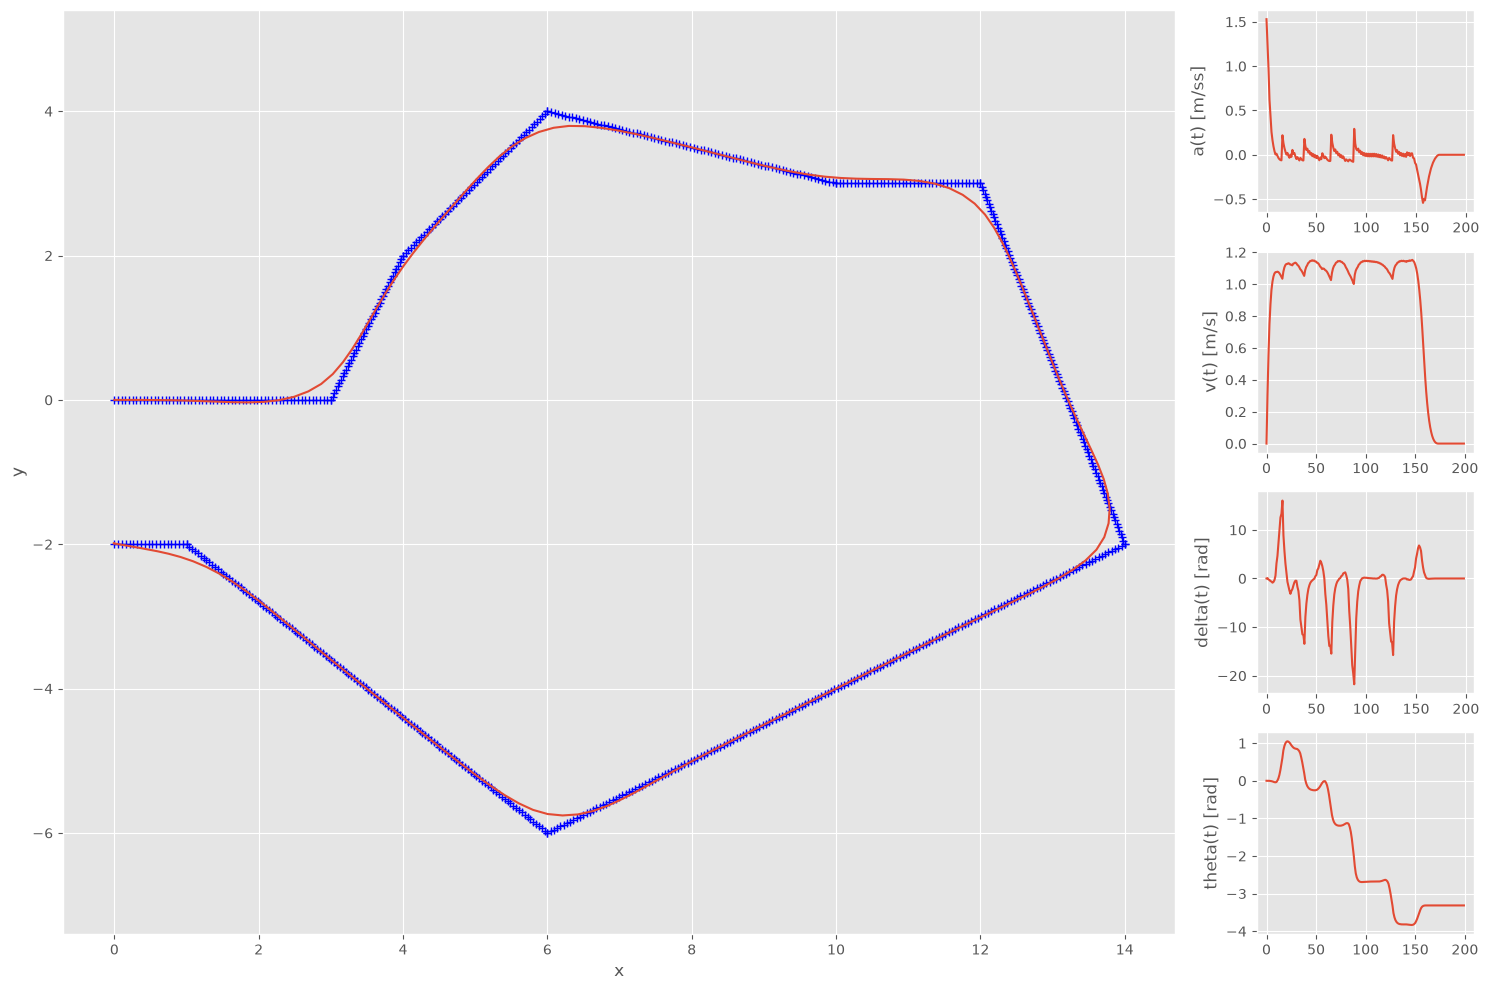

In [14]:
# plot trajectory
grid = plt.GridSpec(4, 5)

plt.figure(figsize=(15, 10))

plt.subplot(grid[0:4, 0:4])
plt.plot(track[0, :], track[1, :], "b+")
plt.plot(x_sim[0, :], x_sim[1, :])
plt.axis("equal")
plt.ylabel("y")
plt.xlabel("x")

plt.subplot(grid[0, 4])
plt.plot(u_sim[0, :])
plt.ylabel("a(t) [m/ss]")

plt.subplot(grid[1, 4])
plt.plot(x_sim[2, :])
plt.ylabel("v(t) [m/s]")

plt.subplot(grid[2, 4])
plt.plot(np.degrees(u_sim[1, :]))
plt.ylabel("delta(t) [rad]")

plt.subplot(grid[3, 4])
plt.plot(x_sim[3, :])
plt.ylabel("theta(t) [rad]")

plt.tight_layout()
plt.show()